## Importing The Libraries

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)

from warnings import filterwarnings
filterwarnings('ignore')

## Importing The Dataset

In [5]:
df = pd.read_csv("SuperStoreOrders.csv")
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


## Checking The Data Types

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

## Data Cleaning: Converting to Numeric

In [25]:
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['shipping_cost'] = pd.to_numeric(df['shipping_cost'], errors='coerce')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  object        
 1   order_date      20067 non-null  datetime64[ns]
 2   ship_date       19834 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  object        
 4   customer_name   51290 non-null  object        
 5   segment         51290 non-null  object        
 6   state           51290 non-null  object        
 7   country         51290 non-null  object        
 8   market          51290 non-null  object        
 9   region          51290 non-null  object        
 10  product_id      51290 non-null  object        
 11  category        51290 non-null  object        
 12  sub_category    51290 non-null  object        
 13  product_name    51290 non-null  object        
 14  sales           48660 non-null  float64       
 15  qu

## Descriptive Statistics

In [7]:
df.describe()

,quantity,discount,profit,shipping_cost,year
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,3.476545,0.142908,28.641740,26.375915,2012.777208
std,2.278766,0.212280,174.424113,57.296804,1.098931
min,1.000000,0.000000,-6599.978000,0.000000,2011.000000
25%,2.000000,0.000000,0.000000,2.610000,2012.000000
50%,3.000000,0.000000,9.240000,7.790000,2013.000000
75%,5.000000,0.200000,36.810000,24.450000,2014.000000
max,14.000000,0.850000,8399.976000,933.570000,2014.000000


## Data Cleaning: Removing Duplicates

In [8]:
df.drop_duplicates(inplace=True)

## Data Cleaning: Date Conversion

In [27]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True, errors='coerce')

In [50]:
print(df['order_date'].head())
print(df['ship_date'].head())

0   2011-01-01
1   2011-01-01
2   2011-01-01
3   2011-01-01
4   2011-01-01
Name: order_date, dtype: datetime64[ns]
0   2011-01-06
1   2011-01-08
2   2011-01-05
3   2011-01-05
4   2011-01-08
Name: ship_date, dtype: datetime64[ns]


## Missing Value Analysis

In [29]:
df.isnull().sum()

order_id              0
order_date        31223
ship_date         31456
ship_mode             0
customer_name         0
segment               0
state                 0
country               0
market                0
region                0
product_id            0
category              0
sub_category          0
product_name          0
sales              2630
quantity              0
discount              0
profit                0
shipping_cost         0
order_priority        0
year                  0
dtype: int64

## Data Cleaning: Handling Missing Values

In [30]:
df = df.dropna(subset=['order_date', 'order_id'])

In [31]:
df['sales'].fillna(df['sales'].median(), inplace=True)

In [32]:
df = df.dropna(subset=['ship_date'])

In [33]:
df.isnull().sum()

order_id          0
order_date        0
ship_date         0
ship_mode         0
customer_name     0
segment           0
state             0
country           0
market            0
region            0
product_id        0
category          0
sub_category      0
product_name      0
sales             0
quantity          0
discount          0
profit            0
shipping_cost     0
order_priority    0
year              0
dtype: int64

## Dataset Shape

In [34]:
df.shape

(13297, 21)

## OUTLIER ANALYSIS

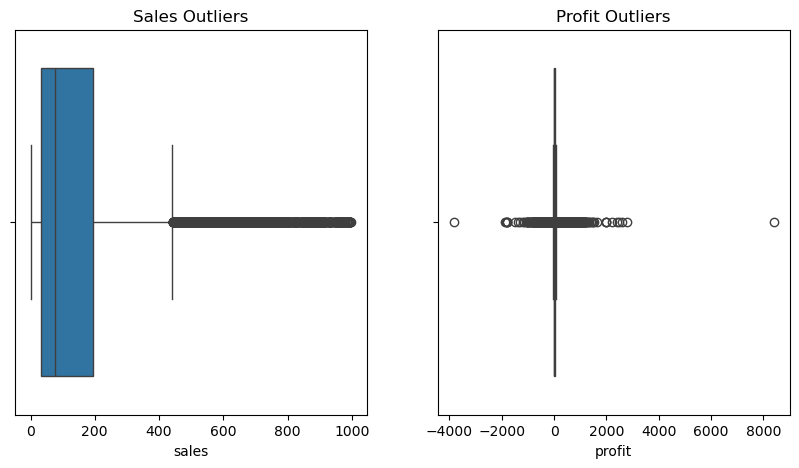

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.boxplot(x=df['sales'])
plt.title("Sales Outliers")

plt.subplot(1,2,2)
sns.boxplot(x=df['profit'])
plt.title("Profit Outliers")

plt.show()

In [58]:
print("Max Sales:", df['sales'].max())
print("Min Profit:", df['profit'].min())

Max Sales: 998.0
Min Profit: -3839.9904


## Outlier Analysis

###  Observation
- From the boxplots, I observed that both **sales** and **profit** columns contain outliers.
- There are some very high sales values, indicating large transactions.
- Profit also shows extreme values, including both high profit and negative profit (loss).

### Understanding
- These outliers are not errors in the data.
- High sales values likely represent bulk purchases or high-value orders.
- Negative profit values indicate situations where discounts or costs exceeded revenue.

### Decision
- I chose **not to remove these outliers**, as they represent real-world business scenarios.

###  Conclusion
- Keeping these values helps in understanding actual business behavior and ensures that important insights are not lost during analysis.

## EDA 

### OVERALL BUSINESS METRICS

In [36]:
total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_orders = df['order_id'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2084080.0
Total Profit: 400896.38758
Total Orders: 6717


### SALES BY REGION

In [37]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
region_sales

region
Central           465126.0
South             267806.0
North             204265.0
Oceania           171808.0
EMEA              165472.0
Southeast Asia    146062.0
Africa            140630.0
North Asia        130993.0
East              107278.0
West              101690.0
Central Asia      100614.0
Caribbean          64730.0
Canada             17606.0
Name: sales, dtype: float64

### PROFIT BY CATEGORY

In [38]:
category_profit = df.groupby('category')['profit'].sum().sort_values(ascending=False)
category_profit

category
Technology         184706.93648
Office Supplies    135415.36570
Furniture           80774.08540
Name: profit, dtype: float64

### SUB-CATEGORY ANALYSIS

In [39]:
subcat_profit = df.groupby('sub_category')['profit'].sum().sort_values()
subcat_profit

sub_category
Tables        -11031.73580
Fasteners       2973.44850
Labels          3794.55310
Supplies        4610.26830
Envelopes       8808.43620
Furnishings    11487.20860
Paper          14978.37430
Binders        15498.16610
Art            16401.05340
Machines       21470.14680
Storage        27520.72170
Accessories    36361.62340
Bookcases      40048.99910
Chairs         40269.61350
Appliances     40830.34410
Phones         48300.16720
Copiers        78574.99908
Name: profit, dtype: float64

### DISCOUNT IMPACT

In [40]:
df[['discount','profit']].corr()

,discount,profit
discount,1.000000,-0.312104
profit,-0.312104,1.000000


### MONTHLY SALES TREND

In [41]:
df['month'] = df['order_date'].dt.month

monthly_sales = df.groupby('month')['sales'].sum()
monthly_sales

month
1      97617.0
2      90649.0
3     132246.0
4     120370.0
5     146117.0
6     211668.0
7     125485.0
8     210422.0
9     227406.0
10    195373.0
11    263023.0
12    263704.0
Name: sales, dtype: float64

### VISUALIZATION

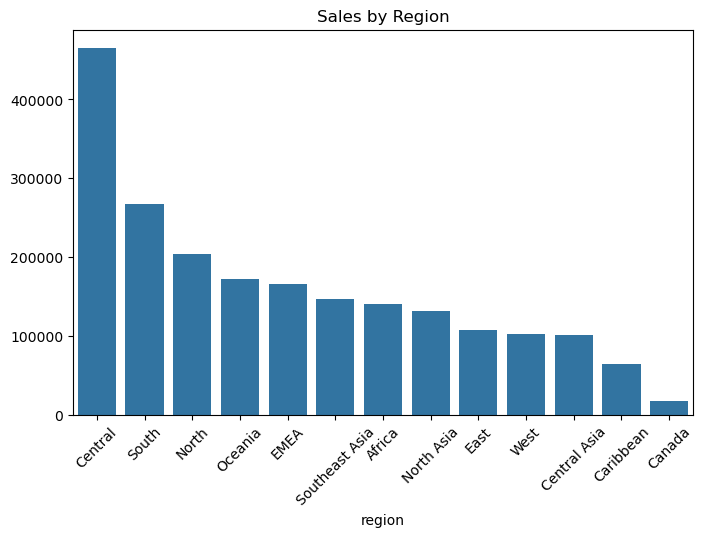

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Sales by Region")
plt.xticks(rotation=45)
plt.show()

### Profit by Category

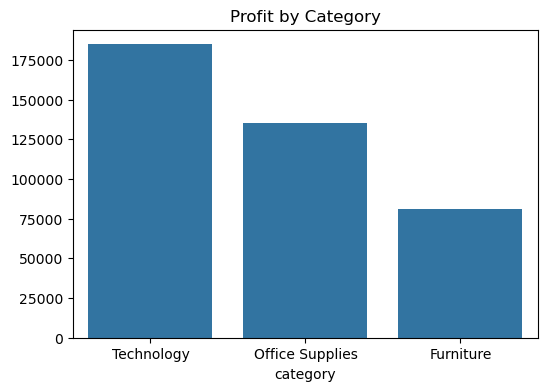

In [44]:
plt.figure(figsize=(6,4))
sns.barplot(x=category_profit.index, y=category_profit.values)
plt.title("Profit by Category")
plt.show()

### Monthly Trend

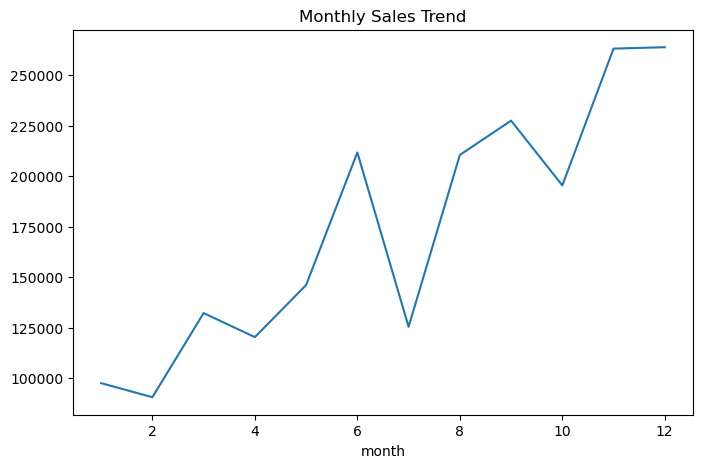

In [45]:
plt.figure(figsize=(8,5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.show()

## Business Insights

### Key Insights from Analysis:
<ol>
<li><b>Central region</b> has the highest sales → strong customer demand.</li><br>
<li><b>Technology category</b> generates highest profit; <b>Furniture</b> is lowest.</li><br>
<li><b>Tables</b> are generating losses → high discounts/costs.</li><br>
<li><b>Discount vs Profit</b> shows negative correlation (-0.31).</li><br>
<li><b>Seasonality observed</b> → peak sales in Nov & Dec.</li><br>
<li><b>Low-performing regions</b>: Canada, Caribbean.</li>
</ol>

## EXPORT DATA FOR DASHBOARD

In [47]:
df.to_csv("cleaned_sales_data.csv", index=False)

## ML Model

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# select features
df_encoded = pd.get_dummies(df[['category','region','discount','quantity','profit','shipping_cost']], drop_first=True)

X = df_encoded
y = df['sales']

# split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model
model = LinearRegression()
model.fit(X_train, y_train)

# predictions
y_pred = model.predict(X_test)

In [56]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.2775094880248009

## Machine Learning Insight

### Model Performance
- The Linear Regression model achieved an **R² score of 0.27**, indicating a moderate level of predictive performance.

###  Key Observation
- The model performance improved after including additional features such as **region, category, profit, and shipping cost**.
- However, the model still does not fully capture the complexity of sales behavior.

###  Interpretation
- Sales cannot be accurately predicted using only a limited set of variables.
- The relatively low R² score suggests that **sales are influenced by multiple external factors** such as customer preferences, seasonal demand, and product characteristics.

###  Conclusion
- This highlights the importance of **feature engineering and domain understanding** in predictive modeling.
- A more advanced model or additional features may further improve prediction accuracy.

In [1]:
pwd

'C:\\Users\\kirut\\sales-data-analysis'